# Load Data


In [20]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)

raw = pd.read_excel('crime_dataset_2023.xlsx')
print(raw.shape)
raw.head()

(231823, 28)


,DR_NO,Date_Rptd,DATE_OCC,TIME_OCC,AREA,AREA_NAME,Rpt_Dist_No,Part_1_2,Crm_Cd,Crm_Cd_Desc,...,Status,Status_Desc,Crm_Cd_1,Crm_Cd_2,Crm_Cd_3,Crm_Cd_4,LOCATION,Cross_Street,LAT,LON
0,230611294,06/17/2023 12:00:00 AM,2023-06-17,1140,6,Hollywood,668,1,442,SHOPLIFTING - PETTY THEFT ($950 & UNDER),...,IC,Invest Cont,442.0,NaN,NaN,NaN,5500 W SUNSET BL,NaN,34.0981,-118.3092
1,230106843,02/12/2023 12:00:00 AM,2023-02-11,1630,1,Central,191,1,440,THEFT PLAIN - PETTY ($950 & UNDER),...,IC,Invest Cont,440.0,NaN,NaN,NaN,1400 WRIGHT ST,NaN,34.0396,-118.2726
2,231515059,09/19/2023 12:00:00 AM,2023-09-19,1030,15,N Hollywood,1549,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,761.0,NaN,NaN,BURBANK BL,CAHUENGA BL,34.1721,-118.3616
3,230110347,04/11/2023 12:00:00 AM,2023-04-10,816,1,Central,192,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,1300 S FLOWER ST,NaN,34.0401,-118.2669
4,230618504,12/01/2023 12:00:00 AM,2023-12-01,110,6,Hollywood,639,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,AO,Adult Other,626.0,NaN,NaN,NaN,5400 RUSSELL AV,NaN,34.1042,-118.3072


# Data Quality Review and Data Wrangling

In [21]:
# Data Quality Review
print("Missing Values:")
miss_before = raw.isna().sum()
print(miss_before[miss_before > 0].sort_values(ascending=False))

print("\nTotal Missing Value:", raw.isna().sum().sum())
print("Vict_Age tidak valid (<=0):", (raw['Vict_Age'] <= 0).sum())
print("Vict_Sex kode aneh:", raw.loc[~raw['Vict_Sex'].isin(['M','F','X']) & raw['Vict_Sex'].notna(), 'Vict_Sex'].unique())
print("Koordinat (0,0) invalid:", ((raw['LAT']==0)|(raw['LON']==0)).sum())
print("Duplikat:", raw['DR_NO'].duplicated().sum())

Missing Values:
Crm_Cd_4          231809
Crm_Cd_3          231297
Crm_Cd_2          216383
Cross_Street      199005
Weapon_Used_Cd    153172
Weapon_Desc       153172
Mocodes            33183
Vict_Descent       31449
Vict_Sex           31445
Premis_Desc          224
Crm_Cd_1               4
Premis_Cd              2
dtype: int64

Total Missing Value: 1281145
Vict_Age tidak valid (<=0): 63559
Vict_Sex kode aneh: <StringArray>
['H', '-']
Length: 2, dtype: str
Koordinat (0,0) invalid: 4
Duplikat: 0


In [22]:
# Data Wrangling
df = raw.copy()

# Drop kolom yang >85% kosong dan tidak relevan untuk model
df = df.drop(columns=['Cross_Street', 'Crm_Cd_2', 'Crm_Cd_3', 'Crm_Cd_4', 'Mocodes'])

# Feature waktu
df['DATE_OCC'] = pd.to_datetime(df['DATE_OCC'])
df['Date_Rptd'] = pd.to_datetime(df['Date_Rptd'])
df['Month_OCC'] = df['DATE_OCC'].dt.month
df['DayOfWeek_OCC'] = df['DATE_OCC'].dt.day_name()
df['Hour_OCC'] = (df['TIME_OCC'] // 100).clip(0, 23)
df['ReportDelay_Days'] = (df['Date_Rptd'] - df['DATE_OCC']).dt.days
df.loc[df['ReportDelay_Days'] < 0, 'ReportDelay_Days'] = np.nan  # delay negatif = error

# Fix demografi korban: kode aneh & missing -> 'X' (Unknown, konvensi LAPD sendiri)
df['Vict_Sex'] = df['Vict_Sex'].replace({'-': np.nan, 'H': np.nan}).fillna('X')
df['Vict_Descent'] = df['Vict_Descent'].replace({'-': np.nan}).fillna('X')

# Usia negatif yang error datanya diubah menjadi missing. Usia 0 TIDAK dihapus (valid utk crime tanpa korban)
df.loc[df['Vict_Age'] < 0, 'Vict_Age'] = np.nan

# Weapon kosong (TIDAK ADA senjata) diubah menjadi NONE
df['Weapon_Used_Cd'] = df['Weapon_Used_Cd'].fillna(0)
df['Weapon_Desc'] = df['Weapon_Desc'].fillna('NONE/NOT INVOLVED')

# Premise: missing sedikit diisi dengan modus
df['Premis_Desc'] = df['Premis_Desc'].fillna(df['Premis_Desc'].mode()[0])
df['Premis_Cd'] = df['Premis_Cd'].fillna(df['Premis_Cd'].mode()[0])

# Crm_Cd_1 kosong didrop karena tidak bisa diklasifikasi
df = df.dropna(subset=['Crm_Cd_1'])

# Koordinat (0,0) invalid jadi di drop
df = df[(df['LAT'] != 0) & (df['LON'] != 0)]

# Definisikan target: Cleared = kasus berakhir dengan penangkapan (Arrest)
df = df[df['Status_Desc'] != 'UNK']
df['Cleared'] = df['Status_Desc'].isin(['Adult Arrest', 'Juv Arrest']).astype(int)

print("After Wrangling:")
print("Shape:", df.shape, "| Rows dropped:", raw.shape[0] - df.shape[0])
print("Missing tersisa:\n", df.isna().sum()[df.isna().sum() > 0])
print("Clearance rate:", df['Cleared'].mean())

/var/folders/8g/ywmvwl117s389t3ylt75v78h0000gn/T/ipykernel_44381/2037752079.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date_Rptd'] = pd.to_datetime(df['Date_Rptd'])


After Wrangling:
Shape: (231813, 28) | Rows dropped: 10
Missing tersisa:
 Vict_Age    3
dtype: int64
Clearance rate: 0.08417560706258924


In [23]:
# Data Quality Index (DQI)
print(f"Missing cells: {raw.isna().sum().sum():,} -> {df.isna().sum().sum():,}")
print(f"Rows dropped: {raw.shape[0]-df.shape[0]} ({(raw.shape[0]-df.shape[0])/raw.shape[0]*100:.3f}%)")
print(f"Invalid Vict_Age (<0) fixed: {(raw['Vict_Age']<0).sum()}")
print(f"Invalid coordinates fixed: {((raw['LAT']==0)|(raw['LON']==0)).sum()}")

Missing cells: 1,281,145 -> 3
Rows dropped: 10 (0.004%)
Invalid Vict_Age (<0) fixed: 3
Invalid coordinates fixed: 4


# Advanced Pattern, Trend & Relationship Analysis

In [ ]:
# SEGMENTED ANALYSIS

# Per area
print("CLEARANCE RATE PER AREA:")
print(df.groupby('AREA_NAME')['Cleared'].agg(['mean','count']).sort_values('mean', ascending=False))

# Per jenis crime (top 15 volume)
top_crimes = df['Crm_Cd_Desc'].value_counts().head(15).index
print("\nCLEARANCE RATE PER JENIS CRIME:")
print(df[df['Crm_Cd_Desc'].isin(top_crimes)].groupby('Crm_Cd_Desc')['Cleared'].agg(['mean','count']).sort_values('mean', ascending=False))

# Per keterlibatan senjata
df['Weapon_Involved'] = (df['Weapon_Used_Cd'] != 0).astype(int)
print("\nCLEARANCE RATE: SENJATA TERLIBAT vs TIDAK:")
print(df.groupby('Weapon_Involved')['Cleared'].agg(['mean','count']))

# Trend bulanan (time-based trend)
print("\nCLEARANCE RATE PER BULAN (trend musiman):")
print(df.groupby('Month_OCC')['Cleared'].agg(['mean','count']))

# Report delay vs clearance
df['ReportDelay_Bucket'] = pd.cut(df['ReportDelay_Days'].fillna(-1),
    bins=[-2,-1,0,1,7,30,10000], labels=['Unknown','SameDay','1Day','2-7Hari','8-30Hari','>30Hari'])
print("\nCLEARANCE RATE vs KECEPATAN LAPOR:")
print(df.groupby('ReportDelay_Bucket')['Cleared'].agg(['mean','count']))

CLEARANCE RATE PER AREA:
                 mean  count
AREA_NAME                   
Harbor       0.128306   9111
N Hollywood  0.121020  11527
Topanga      0.115904   9620
Mission      0.114869   8958
Foothill     0.112279   7134
Van Nuys     0.109599   9918
Rampart      0.108458  11516
West Valley  0.100938   9917
Northeast    0.080735   9686
Southwest    0.080654  13093
77th Street  0.080437  13924
Newton       0.076026  11917
Hollenbeck   0.076016   8393
Devonshire   0.074401   9731
Hollywood    0.071129  11430
Southeast    0.066336  11276
Wilshire     0.065976  11686
Olympic      0.065251  11724
West LA      0.061530  10564
Central      0.055962  16940
Pacific      0.054262  13748

CLEARANCE RATE PER JENIS CRIME:
                                                        mean  count
Crm_Cd_Desc                                                        
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT      0.215411  12692
ROBBERY                                             0.203679   7610
INT

In [25]:
# Variabel yang paling berpengaruh + Evidence Statistik
print("Hubungan Tiap Variabel Terhadap Clearance :")
for col in ['AREA_NAME','Crm_Cd_Desc','Vict_Sex','Vict_Descent','Weapon_Involved','Part_1_2']:
    tab = pd.crosstab(df[col], df['Cleared'])
    chi2, p, dof, exp = chi2_contingency(tab)
    n = tab.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
    print(f"{col:18s} chi2={chi2:10.1f}  p={p:.2e}  Cramers_V={cramers_v:.3f}")

Hubungan Tiap Variabel Terhadap Clearance :
AREA_NAME          chi2=    1565.7  p=0.00e+00  Cramers_V=0.082
Crm_Cd_Desc        chi2=   20653.1  p=0.00e+00  Cramers_V=0.298
Vict_Sex           chi2=     240.6  p=5.71e-53  Cramers_V=0.032
Vict_Descent       chi2=    1304.8  p=3.74e-266  Cramers_V=0.075
Weapon_Involved    chi2=    7759.9  p=0.00e+00  Cramers_V=0.183
Part_1_2           chi2=     151.0  p=1.03e-34  Cramers_V=0.026


# Evaluasi Metode Analitik & Metrik


In [ ]:
# Modeling
features = ['AREA_NAME', 'Crm_Cd_Desc', 'Vict_Sex', 'Vict_Descent', 'Premis_Desc','Weapon_Used_Cd', 'Hour_OCC', 'Month_OCC', 'DayOfWeek_OCC', 'Part_1_2', 'Vict_Age']

model_df = df[features + ['Cleared']].copy()
model_df['Weapon_Involved'] = (model_df['Weapon_Used_Cd'] != 0).astype(int)
model_df = model_df.drop(columns=['Weapon_Used_Cd'])
model_df['Vict_Age'] = model_df['Vict_Age'].fillna(model_df['Vict_Age'].median())

# kategori jarang jadi Other
for col, n in [('Crm_Cd_Desc', 20), ('Premis_Desc', 15)]:
    top = model_df[col].value_counts().head(n).index
    model_df[col] = model_df[col].where(model_df[col].isin(top), 'Other')

cat_cols = ['AREA_NAME', 'Crm_Cd_Desc', 'Vict_Sex', 'Vict_Descent', 'Premis_Desc', 'DayOfWeek_OCC']
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

X = model_df.drop(columns=['Cleared'])
y = model_df['Cleared']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
# Logistic Regression
LR = LogisticRegression(max_iter=1000, class_weight='balanced')
LR.fit(X_train, y_train)
pred_LR = LR.predict(X_test)
prob_LR = LR.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print("Accuracy :", accuracy_score(y_test, pred_LR))
print("Precision:", precision_score(y_test, pred_LR))
print("Recall   :", recall_score(y_test, pred_LR))
print("F1       :", f1_score(y_test, pred_LR))
print("ROC-AUC  :", roc_auc_score(y_test, prob_LR))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_LR))

LOGISTIC REGRESSION
Accuracy : 0.6837780126393892
Precision: 0.17759530088707745
Recall   : 0.7591596208045094
F1       : 0.2878515568076942
ROC-AUC  : 0.7834629846794662
Confusion Matrix:
 [[28739 13721]
 [  940  2963]]


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Random Forest
RF = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced',random_state=42, n_jobs=-1)
RF.fit(X_train, y_train)
pred_RF = RF.predict(X_test)
prob_RF = RF.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print("Accuracy :", accuracy_score(y_test, pred_RF))
print("Precision:", precision_score(y_test, pred_RF))
print("Recall   :", recall_score(y_test, pred_RF))
print("F1       :", f1_score(y_test, pred_RF))
print("ROC-AUC  :", roc_auc_score(y_test, prob_RF))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_RF))

RANDOM FOREST
Accuracy : 0.7199059594935617
Precision: 0.19378329175375902
Recall   : 0.7363566487317448
F1       : 0.3068218212874987
ROC-AUC  : 0.7934715212967693
Confusion Matrix:
 [[30503 11957]
 [ 1029  2874]]


In [29]:
# ACCURACY
baseline_pred = np.zeros(len(y_test))
print("Baseline accuracy:", accuracy_score(y_test, baseline_pred))
print("-> Accuracy tinggi (~92%) tapi recall=0, gunanya nol. Makanya pakai Recall & ROC-AUC sebagai metrik utama.")

Baseline accuracy: 0.9158164915989043
-> Accuracy tinggi (~92%) tapi recall=0, gunanya nol. Makanya pakai Recall & ROC-AUC sebagai metrik utama.


In [ ]:
# FEATURE IMPORTANCE
importance = pd.Series(RF.feature_importances_, index=X.columns).sort_values(ascending=False)
print("TOP 15 FEATURE IMPORTANCE (Random Forest):")
print(importance.head(15))

# Ringkasan perbandingan model
summary = pd.DataFrame({
    'LogReg': [accuracy_score(y_test,pred_LR), precision_score(y_test,pred_LR),recall_score(y_test,pred_LR), f1_score(y_test,pred_LR), roc_auc_score(y_test,prob_LR)],
    'RandomForest': [accuracy_score(y_test,pred_RF), precision_score(y_test,pred_RF),recall_score(y_test,pred_RF), f1_score(y_test,pred_RF), roc_auc_score(y_test,prob_RF)]
}, index=['Accuracy','Precision','Recall','F1','ROC-AUC'])
print("\nRingkasan Perbandingan Model:")
print(summary.round(3))

TOP 15 FEATURE IMPORTANCE (Random Forest):
Weapon_Involved                                                    0.241999
Crm_Cd_Desc_THEFT OF IDENTITY                                      0.066326
Crm_Cd_Desc_BURGLARY FROM VEHICLE                                  0.052523
Crm_Cd_Desc_BATTERY - SIMPLE ASSAULT                               0.044274
Crm_Cd_Desc_THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)    0.042091
Vict_Age                                                           0.041858
Crm_Cd_Desc_THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)        0.038108
Crm_Cd_Desc_VEHICLE - STOLEN                                       0.037604
Crm_Cd_Desc_THEFT PLAIN - PETTY ($950 & UNDER)                     0.034344
Part_1_2                                                           0.026846
Vict_Descent_H                                                     0.022454
Crm_Cd_Desc_ROBBERY                                                0.021076
Crm_Cd_Desc_INTIMATE PARTNER - AGGRAVATED ASS

In [32]:
# Data pendukung untuk rekomendasi 1: prioritas alokasi detektif per jenis crime
print("CLEARANCE RATE TERENDAH vs TERTINGGI (untuk rekomendasi alokasi resource):")
crime_summary = df.groupby('Crm_Cd_Desc')['Cleared'].agg(['mean','count'])
crime_summary = crime_summary[crime_summary['count'] >= 1000]  # filter crime dgn volume cukup
print("5 TERTINGGI:\n", crime_summary.sort_values('mean', ascending=False).head(5))
print("\n5 TERENDAH:\n", crime_summary.sort_values('mean').head(5))

# Data pendukung untuk rekomendasi 2: dampak kecepatan lapor
print("\nDAMPAK KECEPATAN LAPOR PADA CLEARANCE (untuk rekomendasi kampanye pelaporan cepat):")
print(df.groupby('ReportDelay_Bucket')['Cleared'].agg(['mean','count']))

CLEARANCE RATE TERENDAH vs TERTINGGI (untuk rekomendasi alokasi resource):
5 TERTINGGI:
                                                     mean  count
Crm_Cd_Desc                                                    
INTIMATE PARTNER - AGGRAVATED ASSAULT           0.312709   2990
ATTEMPTED ROBBERY                               0.223978   1076
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT  0.215411  12692
ROBBERY                                         0.203679   7610
INTIMATE PARTNER - SIMPLE ASSAULT               0.183874  10877

5 TERENDAH:
                                                         mean  count
Crm_Cd_Desc                                                        
PICKPOCKET                                          0.002412   1244
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)     0.003894   7961
BIKE - STOLEN                                       0.004894   1226
THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND O...  0.006826   8936
THEFT OF IDENTITY                        

# Visualization

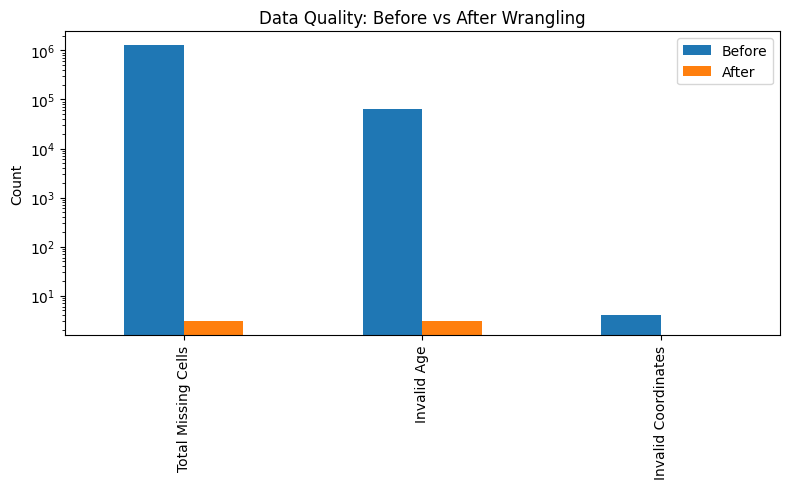

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Missing values before vs after
before_after = pd.DataFrame({
    'Before': [1281145, (raw['Vict_Age']<=0).sum(), 4],
    'After': [df.isna().sum().sum(), 3, 0]
}, index=['Total Missing Cells', 'Invalid Age', 'Invalid Coordinates'])

before_after.plot(kind='bar', figsize=(8,5))
plt.title('Data Quality: Before vs After Wrangling')
plt.ylabel('Count')
plt.yscale('log')  
plt.tight_layout()
plt.show()

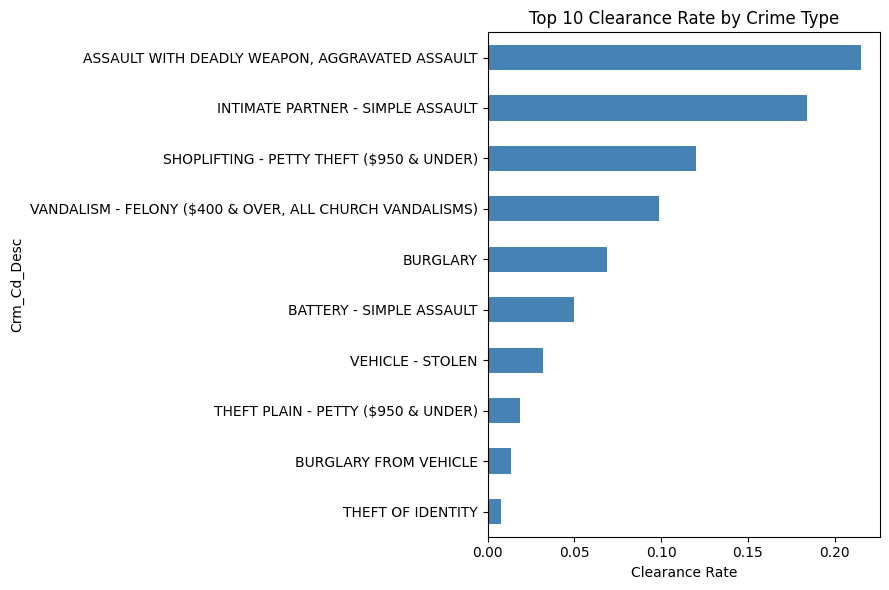

In [ ]:
# Clearance rate per jenis crime
top_crimes = df['Crm_Cd_Desc'].value_counts().head(10).index
crime_rate = df[df['Crm_Cd_Desc'].isin(top_crimes)].groupby('Crm_Cd_Desc')['Cleared'].mean().sort_values()

plt.figure(figsize=(9,6))
crime_rate.plot(kind='barh', color='steelblue')
plt.title('Top 10 Clearance Rate by Crime Type')
plt.xlabel('Clearance Rate')
plt.tight_layout()
plt.show()

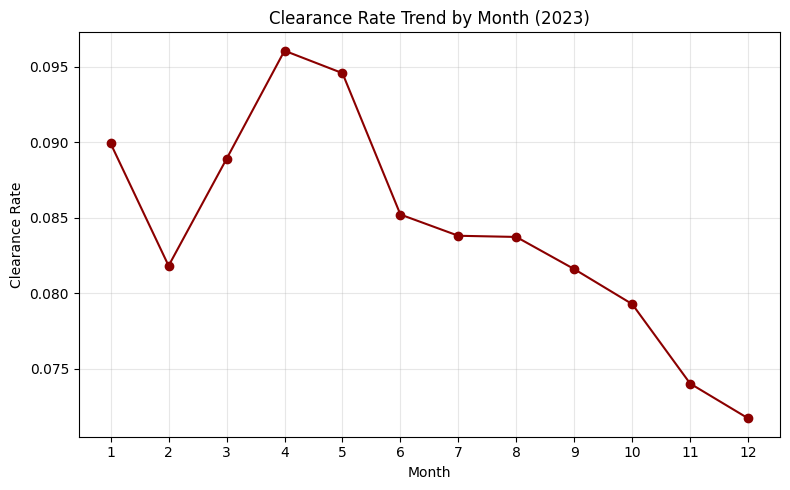

In [ ]:
# Trend bulanan clearance rate
monthly = df.groupby('Month_OCC')['Cleared'].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly.index, monthly.values, marker='o', color='darkred')
plt.title('Clearance Rate Trend by Month (2023)')
plt.xlabel('Month')
plt.ylabel('Clearance Rate')
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/8g/ywmvwl117s389t3ylt75v78h0000gn/T/ipykernel_44381/4169932629.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.index, rotation=45, ha='right')
/var/folders/8g/ywmvwl117s389t3ylt75v78h0000gn/T/ipykernel_44381/4169932629.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(data.index, rotation=45, ha='right')


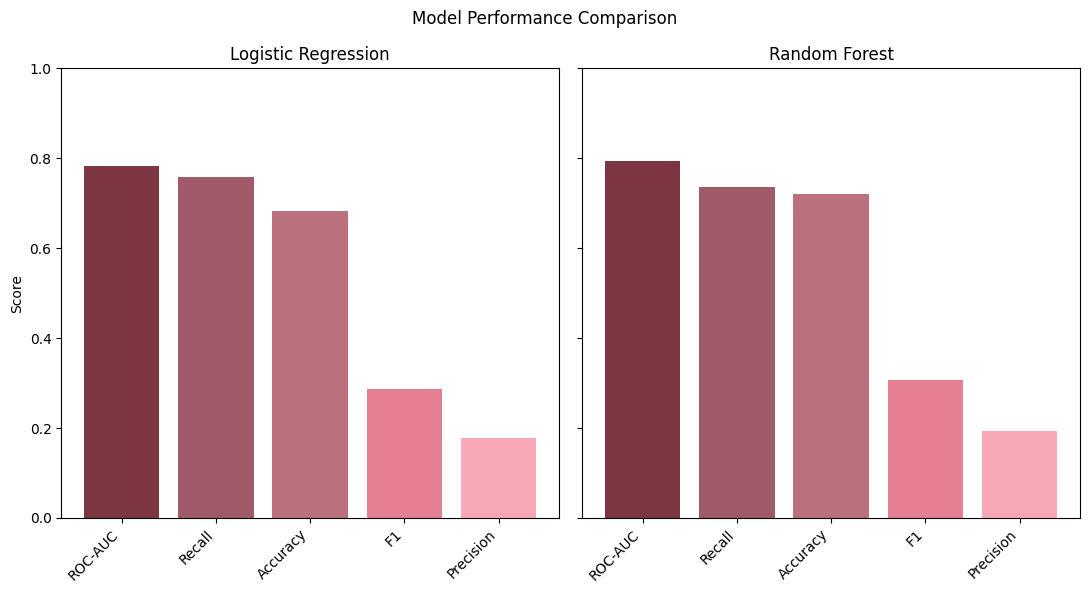

In [ ]:
# Logistic Regression and RandomForest

models = ['LogReg', 'RandomForest']           
display_names = ['Logistic Regression', 'Random Forest'] 

colors = ["#7D3542", "#A05966", "#BB707E", "#E57F92", "#F9A8B7"]

fig, axes = plt.subplots(1, 2, figsize=(11,6), sharey=True)

for ax, model, label in zip(axes, models, display_names):
    data = summary[model].sort_values(ascending=False)
    ax.bar(data.index, data.values, color=colors[:len(data)])
    ax.set_title(label)
    ax.set_xticklabels(data.index, rotation=45, ha='right')
    ax.set_ylim(0, 1)

axes[0].set_ylabel('Score')
fig.suptitle('Model Performance Comparison')
plt.tight_layout()
plt.show()

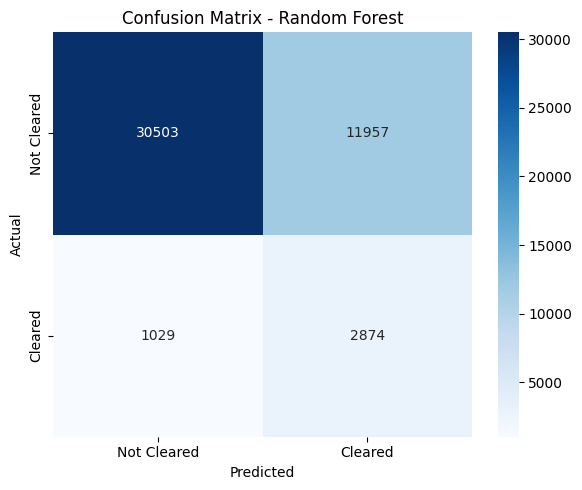

In [ ]:
# Confusion matrix Random Forest
cm = confusion_matrix(y_test, pred_RF)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Cleared','Cleared'], yticklabels=['Not Cleared','Cleared'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()